# Prepare Eastern Victoria gravimeter data

This tutorial demonstrates the preparation of XYZ airborne gravity data for QC.
___

First, import the required python packages, ...

In [1]:
from pathlib import Path
import pegasusQC as qc

... then set the path to the geowhizz files.

This is all very much step by step to illustrate the process, and you can certainly compress some of these steps in your own work.

In [2]:
# Our survey data consists of 4 XYZ files, all in the same directory.
data_root = r'./EastVicData/'

# The name of the input file for the survey data.
EastVicXYZ_file = Path(data_root + r'EastVic.xyz')

# For the EastVic survey, we have test line data in a separate XYZ file ...
EastVicTestXYZ_file = Path(data_root + r'EastVicTest.xyz')

# ... and another XYZ file with the repeat line data.
EastVicRepXYZ_file = Path(data_root + r'EastVicRepeats.xyz')

# Finally, we also have the planned drape file, or plan file.
# ... sometimes, but not this time, the plan data is in a different directory.
plan_root = data_root
EastVicXYZ_plan = Path(plan_root + r'EastVicPlan.xyz')

___

**The Survey Plan Data**

Usually (ideally) there is a drape plan data file with the planned positions of the aircraft for each flight-line. It is best to convert the plan data to geowhizz format first because information in the plan can be used to better prepare the survey data.

You can use any `projectName` you like. It is only used in titles for plots.

In [3]:
# Convert the plan data from XYZ to geoWhizz format
EastVicHDF_plan = qc.xyzToHDF(Path(EastVicXYZ_plan), projectName='EastVic')

Accessing XYZ data in EastVicData/EastVicPlan.xyz.
First few records are:
/Clearance_m    Drape_m       Line  Terrain_m W84_Latitude_deg
W84_Longitude_deg W84_UTM_55S_X_m W84_UTM_55S_Y_m
//Flight 0
//Date 2022/03/11
Line  2340

  Found 41 header records
  Found 20 lines
  Found 8 fields

Channel precisions (number of decimal places):
[2 2 2 2 8 8 2 2]
Creating:  EastVicData/EastVicPlan.hdf5


In [4]:
# Add in some meta-data (used in plot titles)
block_name = 'Survey Plan'
qc.updateProject(EastVicHDF_plan, acquirer='Sander Geophysics', blockID=block_name)

Setting BlockID = Survey Plan for EastVicPlan.hdf5.
Setting Acquirer = Sander Geophysics for EastVicPlan.hdf5.


In [5]:
# Set meta-data in the CoordFrame group. The `x`, `y`, and `alt` are the names of
# the default x, y, z channels used in many QC functions. It is advisable to include
# at least these 3 metadata.
qc.updateCoordFrame(EastVicHDF_plan,
                    x='W84_UTM_55S_X_m', 
                    y='W84_UTM_55S_Y_m', 
                    alt='Drape_m', 
                    geoDatum='WGS84', 
                    projection='UTM', 
                    utmz='55')

Changed CoordFrame attribute(s) for EastVicPlan.hdf5.


In [6]:
# Set the attributes for each channel. The `units` are used in plot labels and in
# some QC analysis so should always be set if known. The `descriptions` are rarely
# used, so definitely optional.
qc.updateChannelAttributes(EastVicHDF_plan, 'W84_UTM_55S_X_m', units='m')
qc.updateChannelAttributes(EastVicHDF_plan, 'W84_UTM_55S_Y_m', units='m')
qc.updateChannelAttributes(EastVicHDF_plan, 'Drape_m', units='m', description='Height relative to WGS84')
qc.updateChannelAttributes(EastVicHDF_plan, 'Clearance_m', units='m')
qc.updateChannelAttributes(EastVicHDF_plan, 'Terrain_m', units='m')
qc.updateChannelAttributes(EastVicHDF_plan, 'W84_Latitude_deg', units='deg')
qc.updateChannelAttributes(EastVicHDF_plan, 'W84_Longitude_deg', units='deg')

Changed channel attribute(s) for W84_UTM_55S_X_m in EastVicPlan.hdf5.
Changed channel attribute(s) for W84_UTM_55S_Y_m in EastVicPlan.hdf5.
Changed channel attribute(s) for Drape_m in EastVicPlan.hdf5.
Changed channel attribute(s) for Clearance_m in EastVicPlan.hdf5.
Changed channel attribute(s) for Terrain_m in EastVicPlan.hdf5.
Changed channel attribute(s) for W84_Latitude_deg in EastVicPlan.hdf5.
Changed channel attribute(s) for W84_Longitude_deg in EastVicPlan.hdf5.


In [7]:
# Summary report of the newly created geowhizz plan data file.
qc.reportWhizz(EastVicHDF_plan)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: Survey Plan
    ProjectName: EastVic

Coordinates
    AltitudeChannel: Drape_m
    GeoDatum: WGS84
    Projection: UTM
    UTMZone: 55
    XChannel: W84_UTM_55S_X_m
    YChannel: W84_UTM_55S_Y_m
20 lines: total distance flown [km] = 2,770.8

20 lines:
['2340.000', '2341.000', '2341.100', '2341.500', '2342.000',
'2343.000', '2343.100', '2343.500', '2344.000', '2345.000',
'2345.100', '2345.500', '2346.000', '2347.000', '2347.100',
'2347.500', '2348.000', '2349.000', '2349.100', '2349.500']

8 channels:
['Clearance_m', 'Drape_m', 'Line', 'Terrain_m', 'W84_Latitude_deg',
'W84_Longitude_deg', 'W84_UTM_55S_X_m', 'W84_UTM_55S_Y_m']


___

**The Measured Survey Data**

In [8]:
# Now run through the same steps for the measured data.
EastVicHDF_file = qc.xyzToHDF(Path(EastVicXYZ_file), projectName='EastVic')

Accessing XYZ data in EastVicData/EastVic.xyz.
First few records are:
/    ATMCOR B100s_267_GEOID B100s_267_GRS80 B56s_267_GEOID
B56s_267_GRS80    DEM        DOY     EOTCOR FA100s_GEOID FA100s_GRS80
FA56s_GEOID FA56s_GRS80 FACOR_GEOID FACOR_GRS80     FLIGHT      FTIME
FX         FY         FZ       HDOP   LALT            LAT     LATCOR
LINE           LONG      MGA_X      MGA_Y   MGA_Z   MSL_Z      NSATS
PDOP    RALT    STATCOR      TACOR     V_EAST    V_NORTH       VDOP
YEAR
//Flight 0
//Date 2022/07/13
Line  2341.50

  Found 17 header records
  Found 8 lines
  Found 38 fields

Channel precisions (number of decimal places):
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 8 2 2 8 2 2 2 2 2 2 2 2 2 2
2 2  2]
Creating:  EastVicData/EastVic.hdf5


In [9]:
# The block name appears on some plots, so it is useful to set it so that it
# indicates for which data the plots are shown.
block_name = 'EastVic Field Data'
qc.updateProject(EastVicHDF_file, acquirer='Sander Geophysics', blockID=block_name)

Setting BlockID = EastVic Field Data for EastVic.hdf5.
Setting Acquirer = Sander Geophysics for EastVic.hdf5.


In [10]:
# In measured data, we can also name the default time channel.
qc.updateCoordFrame(EastVicHDF_file, 
                    lat='LAT', 
                    lon='LONG', 
                    x='MGA_X', 
                    y='MGA_Y', 
                    time='FTIME', 
                    alt='MGA_Z',
                    geoDatum='GDA2020', 
                    htDatum='GRS80', 
                    projection='MGA', 
                    utmz='55')

Changed CoordFrame attribute(s) for EastVic.hdf5.


In [11]:
# The `line_type` tells the code how to extract the planned line number, the segment 
# number, and the repeat number from each reported survey line number. This is necessary
# for comparing positioning of measured data aginst planned positions. Flight numbers
# and dates are recorded as line meta-data in the geowhizz file.

# More details on Line Types can be found elsewhere in the documentation.

qc.updateLineAttributes(EastVicHDF_file, planfiles=EastVicHDF_plan, line_type='SGL_GA', flight_chan='FLIGHT', date_chan="DOY")

Setting Line attributes for EastVicData/EastVic.hdf5 to include flight numbers from FLIGHT.
Setting Line attributes for EastVicData/EastVic.hdf5 to include date values from DOY.

Setting Line attributes for EastVic.hdf5 according to the SGL_GA scheme.
Verifying planned line numbers against provided plan file(s).


In [12]:
# The channel metadata are not in the `XYZ` data file and must be delivered separately.
# Particularly important are the units, some of which are used by __pe*ga*susQC__.
# The following command should be run on all data channels which is tedious (but
# necessary). Note that, unlike `XYZ` files, ASEG-GDF2 files include metadata which
# is automatically read into the metadata.

# Set the units for each relevant channel. We could include descriptions for each
# as well if we want, these are only used by `reportChannels`.
qc.updateChannelAttributes(EastVicHDF_file, 'FTIME', units='s')
qc.updateChannelAttributes(EastVicHDF_file, 'MGA_X', units='m')
qc.updateChannelAttributes(EastVicHDF_file, 'MGA_Y', units='m')
qc.updateChannelAttributes(EastVicHDF_file, 'MGA_Z', units='m')
qc.updateChannelAttributes(EastVicHDF_file, 'MSL_Z', units='m')
qc.updateChannelAttributes(EastVicHDF_file, 'LAT', units='degree')
qc.updateChannelAttributes(EastVicHDF_file, 'LONG', units='degree')
qc.updateChannelAttributes(EastVicHDF_file, 'DEM', units='m')
qc.updateChannelAttributes(EastVicHDF_file, 'RALT', units='m')
qc.updateChannelAttributes(EastVicHDF_file, 'LALT', units='m')
qc.updateChannelAttributes(EastVicHDF_file, 'FX', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'FY', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'FZ', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'V_EAST', units='m/s')
qc.updateChannelAttributes(EastVicHDF_file, 'V_NORTH', units='m/s')
qc.updateChannelAttributes(EastVicHDF_file, 'EOTCOR', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'LATCOR', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'STATCOR', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'ATMCOR', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'FACOR_GRS80', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'FACOR_GEOID', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'TACOR', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'FA56s_GRS80', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'FA56s_GEOID', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'FA100s_GRS80', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'FA100s_GEOID', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'B56s_267_GRS80', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'B56s_267_GEOID', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'B100s_267_GRS80', units='mGal')
qc.updateChannelAttributes(EastVicHDF_file, 'B100s_267_GEOID', units='mGal')

Changed channel attribute(s) for FTIME in EastVic.hdf5.
Changed channel attribute(s) for MGA_X in EastVic.hdf5.
Changed channel attribute(s) for MGA_Y in EastVic.hdf5.
Changed channel attribute(s) for MGA_Z in EastVic.hdf5.
Changed channel attribute(s) for MSL_Z in EastVic.hdf5.
Changed channel attribute(s) for LAT in EastVic.hdf5.
Changed channel attribute(s) for LONG in EastVic.hdf5.
Changed channel attribute(s) for DEM in EastVic.hdf5.
Changed channel attribute(s) for RALT in EastVic.hdf5.
Changed channel attribute(s) for LALT in EastVic.hdf5.
Changed channel attribute(s) for FX in EastVic.hdf5.
Changed channel attribute(s) for FY in EastVic.hdf5.
Changed channel attribute(s) for FZ in EastVic.hdf5.
Changed channel attribute(s) for V_EAST in EastVic.hdf5.
Changed channel attribute(s) for V_NORTH in EastVic.hdf5.
Changed channel attribute(s) for EOTCOR in EastVic.hdf5.
Changed channel attribute(s) for LATCOR in EastVic.hdf5.
Changed channel attribute(s) for STATCOR in EastVic.hdf5.
C

In [13]:
qc.reportWhizz(EastVicHDF_file)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Field Data
    ProjectName: EastVic

Coordinates
    AltitudeChannel: MGA_Z
    GeoDatum: GDA2020
    HeightDatum: GRS80
    LatitudeChannel: LAT
    LongitudeChannel: LONG
    Projection: MGA
    TimeChannel: FTIME
    UTMZone: 55
    XChannel: MGA_X
    YChannel: MGA_Y
8 lines: total distance flown [km] = 981.3

8 lines:
['2341.500', '2343.500', '2343.510', '2345.500', '2345.510',
'2347.500', '2349.500', '2349.510']

38 channels:
['ATMCOR', 'B100s_267_GEOID', 'B100s_267_GRS80', 'B56s_267_GEOID',
'B56s_267_GRS80', 'DEM', 'DOY', 'EOTCOR', 'FA100s_GEOID',
'FA100s_GRS80', 'FA56s_GEOID', 'FA56s_GRS80', 'FACOR_GEOID',
'FACOR_GRS80', 'FLIGHT', 'FTIME', 'FX', 'FY', 'FZ', 'HDOP', 'LALT',
'LAT', 'LATCOR', 'LINE', 'LONG', 'MGA_X', 'MGA_Y', 'MGA_Z', 'MSL_Z',
'NSATS', 'PDOP', 'RALT', 'STATCOR', 'TACOR', 'VDOP', 'V_EAST',
'V_NORTH', 'YEAR']


In [14]:
# The report functions allow you to look in more detail at specific elements within
# the data.
qc.reportWhizz(EastVicHDF_file, line='2341.500', channel='ATMCOR')

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Field Data
    ProjectName: EastVic

Coordinates
    AltitudeChannel: MGA_Z
    GeoDatum: GDA2020
    HeightDatum: GRS80
    LatitudeChannel: LAT
    LongitudeChannel: LONG
    Projection: MGA
    TimeChannel: FTIME
    UTMZone: 55
    XChannel: MGA_X
    YChannel: MGA_Y

Line <HDF5 group "/Whizz Version 1.0/Lines/2341.500" (38 members)>
1 lines: total distance flown [km] = 192.3
    Date: 106.0
    Flight: 1012.0
    LineNumber: 2341.5
    LineType: SGL_GA
    LineVariety: Traverse
    PlannedLine: 2341.5
    ReflightNumber: 0
    Segment: 5
['2341.500', '2343.500', '2343.510', '2345.500', '2345.510',
'2347.500', '2349.500', '2349.510']

38 channels:
['ATMCOR', 'B100s_267_GEOID', 'B100s_267_GRS80', 'B56s_267_GEOID',
'B56s_267_GRS80', 'DEM', 'DOY', 'EOTCOR', 'FA100s_GEOID',
'FA100s_GRS80', 'FA56s_GEOID', 'FA56s_GRS80', 'FACOR_GEOID',
'FACOR_GRS80', 'FLIGHT', 'FTIME', 'FX', 'FY', 'FZ', 'HDOP', 'LALT',
'LAT', 'LATCOR'

In [15]:
# Setting the `detailed` flag to True provides additional information.
qc.reportFlights(EastVicHDF_file, detailed=True)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Field Data
    ProjectName: EastVic

5 flights including 8 lines.

Flights
    1012
      L2341.500 
    1014
      L2343.500 
    1018
      L2343.510 L2345.500 L2345.510 L2347.500 
    1021
      L2349.500 
    1022
      L2349.510 



In [16]:
# We can also report sampling information, ...
qc.reportSampling(EastVicHDF_file)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Field Data
    ProjectName: EastVic

Sample time and distance statistics
  Min   = 0.500 s, 26.2 m
  Max   = 0.500 s, 32.4 m
  Mean  = 0.500 s, 29.7 m
  Stdev = 0 s, 0.9 m


In [17]:
# ... and the channel information.
qc.reportChannels(EastVicHDF_file)

Whizz Version 1.0

38 channels:


38 channels:
['ATMCOR', 'B100s_267_GEOID', 'B100s_267_GRS80', 'B56s_267_GEOID',
'B56s_267_GRS80', 'DEM', 'DOY', 'EOTCOR', 'FA100s_GEOID',
'FA100s_GRS80', 'FA56s_GEOID', 'FA56s_GRS80', 'FACOR_GEOID',
'FACOR_GRS80', 'FLIGHT', 'FTIME', 'FX', 'FY', 'FZ', 'HDOP', 'LALT',
'LAT', 'LATCOR', 'LINE', 'LONG', 'MGA_X', 'MGA_Y', 'MGA_Z', 'MSL_Z',
'NSATS', 'PDOP', 'RALT', 'STATCOR', 'TACOR', 'VDOP', 'V_EAST',
'V_NORTH', 'YEAR']


___

**The Measured Test-Line Data**

The test line data have all the same properties as the survey data, so we repeat all the same steps, but for different input and output files.
And we change the block name.

<div class="alert alert-block alert-warning">
WARNING - 
The supplier used underscores in the channel names for the survey data (coordinates and Bouguer gravity), but dashes for the repeat and test line data (e.g. `MGA_X` vs `MGA-X`). So we must get that right for `updateCoordFrame` and `updateChannelAttributes`.
<div>

In [18]:
EastVicTestHDF_file = qc.xyzToHDF(EastVicTestXYZ_file, projectName='EastVic')

Accessing XYZ data in EastVicData/EastVicTest.xyz.
First few records are:
/
/
/   LINE FLIGHT  YEAR  DOY      FTIME       MGA-X       MGA-Y
MGA-Z      MSL-Z           LAT          LONG    PDOP    VDOP    HDOP
NSATS         DEM        RALT        LALT           FX           FY
FZ       V_EAST      V_NORTH       EOTCOR       LATCOR      STATCOR
ATMCOR  FACOR_GRS80  FACOR_GEOID        TACOR  FA56s_GRS80
FA56s_GEOID FA100s_GRS80 FA100s_GEOID B56s-267_GRS80 B56s-267_GEOID
B100s-267_GRS80 B100s-267_GEOID
 Line       8001.04

  Found 3 header records
  Found 4 lines
  Found 38 fields

Channel precisions (number of decimal places):
[2 0 0 0 2 2 2 2 2 7 7 2 2 2 0 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
3 3  3]
Creating:  EastVicData/EastVicTest.hdf5


In [19]:
block_name = 'EastVic Test Line Data'
qc.updateProject(EastVicTestHDF_file, acquirer='Sander Geophysics', blockID=block_name)
qc.updateCoordFrame(EastVicTestHDF_file, 
                    lat='LAT', 
                    lon='LONG', 
                    x='MGA-X', 
                    y='MGA-Y', 
                    time='FTIME', 
                    alt='MGA-Z',
                    geoDatum='GDA2020', 
                    htDatum='GRS80', 
                    projection='MGA', 
                    utmz='55')

Setting BlockID = EastVic Test Line Data for EastVicTest.hdf5.
Setting Acquirer = Sander Geophysics for EastVicTest.hdf5.
Changed CoordFrame attribute(s) for EastVicTest.hdf5.


In [20]:
qc.updateLineAttributes(EastVicTestHDF_file, planfiles=EastVicHDF_plan, line_type='SGL_GA', flight_chan='FLIGHT', date_chan="DOY")

Setting Line attributes for EastVicData/EastVicTest.hdf5 to include flight numbers from FLIGHT.
Setting Line attributes for EastVicData/EastVicTest.hdf5 to include date values from DOY.

Setting Line attributes for EastVicTest.hdf5 according to the SGL_GA scheme.
Verifying planned line numbers against provided plan file(s).


In [21]:
qc.updateChannelAttributes(EastVicTestHDF_file, 'FTIME', units='s')
qc.updateChannelAttributes(EastVicTestHDF_file, 'MGA-X', units='m')
qc.updateChannelAttributes(EastVicTestHDF_file, 'MGA-Y', units='m')
qc.updateChannelAttributes(EastVicTestHDF_file, 'MGA-Z', units='m')
qc.updateChannelAttributes(EastVicTestHDF_file, 'MSL-Z', units='m')
qc.updateChannelAttributes(EastVicTestHDF_file, 'LAT', units='degree')
qc.updateChannelAttributes(EastVicTestHDF_file, 'LONG', units='degree')
qc.updateChannelAttributes(EastVicTestHDF_file, 'DEM', units='m')
qc.updateChannelAttributes(EastVicTestHDF_file, 'RALT', units='m')
qc.updateChannelAttributes(EastVicTestHDF_file, 'LALT', units='m')
qc.updateChannelAttributes(EastVicTestHDF_file, 'FX', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'FY', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'FZ', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'V_EAST', units='m/s')
qc.updateChannelAttributes(EastVicTestHDF_file, 'V_NORTH', units='m/s')
qc.updateChannelAttributes(EastVicTestHDF_file, 'EOTCOR', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'LATCOR', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'STATCOR', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'ATMCOR', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'FACOR_GRS80', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'FACOR_GEOID', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'TACOR', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'FA56s_GRS80', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'FA56s_GEOID', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'FA100s_GRS80', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'FA100s_GEOID', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'B56s-267_GRS80', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'B56s-267_GEOID', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'B100s-267_GRS80', units='mGal')
qc.updateChannelAttributes(EastVicTestHDF_file, 'B100s-267_GEOID', units='mGal')

Changed channel attribute(s) for FTIME in EastVicTest.hdf5.
Changed channel attribute(s) for MGA-X in EastVicTest.hdf5.
Changed channel attribute(s) for MGA-Y in EastVicTest.hdf5.
Changed channel attribute(s) for MGA-Z in EastVicTest.hdf5.
Changed channel attribute(s) for MSL-Z in EastVicTest.hdf5.
Changed channel attribute(s) for LAT in EastVicTest.hdf5.
Changed channel attribute(s) for LONG in EastVicTest.hdf5.
Changed channel attribute(s) for DEM in EastVicTest.hdf5.
Changed channel attribute(s) for RALT in EastVicTest.hdf5.
Changed channel attribute(s) for LALT in EastVicTest.hdf5.
Changed channel attribute(s) for FX in EastVicTest.hdf5.
Changed channel attribute(s) for FY in EastVicTest.hdf5.
Changed channel attribute(s) for FZ in EastVicTest.hdf5.
Changed channel attribute(s) for V_EAST in EastVicTest.hdf5.
Changed channel attribute(s) for V_NORTH in EastVicTest.hdf5.
Changed channel attribute(s) for EOTCOR in EastVicTest.hdf5.
Changed channel attribute(s) for LATCOR in EastVicTe

In [22]:
qc.reportWhizz(EastVicTestHDF_file)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Test Line Data
    ProjectName: EastVic

Coordinates
    AltitudeChannel: MGA-Z
    GeoDatum: GDA2020
    HeightDatum: GRS80
    LatitudeChannel: LAT
    LongitudeChannel: LONG
    Projection: MGA
    TimeChannel: FTIME
    UTMZone: 55
    XChannel: MGA-X
    YChannel: MGA-Y
4 lines: total distance flown [km] = 200.4

4 lines:
['8001.040', '8001.050', '8001.060', '8001.070']

38 channels:
['ATMCOR', 'B100s-267_GEOID', 'B100s-267_GRS80', 'B56s-267_GEOID',
'B56s-267_GRS80', 'DEM', 'DOY', 'EOTCOR', 'FA100s_GEOID',
'FA100s_GRS80', 'FA56s_GEOID', 'FA56s_GRS80', 'FACOR_GEOID',
'FACOR_GRS80', 'FLIGHT', 'FTIME', 'FX', 'FY', 'FZ', 'HDOP', 'LALT',
'LAT', 'LATCOR', 'LINE', 'LONG', 'MGA-X', 'MGA-Y', 'MGA-Z', 'MSL-Z',
'NSATS', 'PDOP', 'RALT', 'STATCOR', 'TACOR', 'VDOP', 'V_EAST',
'V_NORTH', 'YEAR']


In [23]:
qc.reportFlights(EastVicTestHDF_file, detailed=False)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Test Line Data
    ProjectName: EastVic

1 flights including 4 lines.

Flights
    2019 



In [24]:
qc.reportSampling(EastVicTestHDF_file)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Test Line Data
    ProjectName: EastVic

Sample time and distance statistics
  Min   = 0.500 s, 27.3 m
  Max   = 0.500 s, 33.2 m
  Mean  = 0.500 s, 30.3 m
  Stdev = 0 s, 1 m


___

**The Measured Repeat-Line Data**

Similarly, the repeat-line data have all the same properties as the survey data, so we repeat all the same steps, but for different input and output files.
Again, we change the block name.

In [25]:
EastVicRepHDF_file = qc.xyzToHDF(EastVicRepXYZ_file, projectName='EastVic')

Accessing XYZ data in EastVicData/EastVicRepeats.xyz.
First few records are:
/
/
/   LINE FLIGHT  YEAR  DOY      FTIME       MGA-X       MGA-Y
MGA-Z      MSL-Z           LAT          LONG    PDOP    VDOP    HDOP
NSATS         DEM        RALT        LALT           FX           FY
FZ       V_EAST      V_NORTH       EOTCOR       LATCOR      STATCOR
ATMCOR  FACOR_GRS80  FACOR_GEOID        TACOR  FA56s_GRS80
FA56s_GEOID FA100s_GRS80 FA100s_GEOID B56s-267_GRS80 B56s-267_GEOID
B100s-267_GRS80 B100s-267_GEOID
 Line       7001.16

  Found 3 header records
  Found 10 lines
  Found 38 fields

Channel precisions (number of decimal places):
[2 0 0 0 2 2 2 2 2 7 7 2 2 2 0 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
3 3  3]
Creating:  EastVicData/EastVicRepeats.hdf5


In [26]:
block_name = 'EastVic Repeat Line Data'
qc.updateProject(EastVicRepHDF_file, acquirer='Sander Geophysics', blockID=block_name)
qc.updateCoordFrame(EastVicRepHDF_file, lat='LAT', lon='LONG', x='MGA-X', y='MGA-Y', time='FTIME', alt='MGA-Z')
qc.updateCoordFrame(EastVicRepHDF_file, geoDatum='GDA2020', htDatum='GRS80', projection='MGA', utmz='55')

Setting BlockID = EastVic Repeat Line Data for EastVicRepeats.hdf5.
Setting Acquirer = Sander Geophysics for EastVicRepeats.hdf5.
Changed CoordFrame attribute(s) for EastVicRepeats.hdf5.
Changed CoordFrame attribute(s) for EastVicRepeats.hdf5.


In [27]:
qc.updateLineAttributes(EastVicRepHDF_file, planfiles=EastVicHDF_plan, line_type='SGL_GA', flight_chan='FLIGHT', date_chan="DOY")

Setting Line attributes for EastVicData/EastVicRepeats.hdf5 to include flight numbers from FLIGHT.
Setting Line attributes for EastVicData/EastVicRepeats.hdf5 to include date values from DOY.

Setting Line attributes for EastVicRepeats.hdf5 according to the SGL_GA scheme.
Verifying planned line numbers against provided plan file(s).


In [28]:
qc.updateChannelAttributes(EastVicRepHDF_file, 'FTIME', units='s')
qc.updateChannelAttributes(EastVicRepHDF_file, 'MGA-X', units='m')
qc.updateChannelAttributes(EastVicRepHDF_file, 'MGA-Y', units='m')
qc.updateChannelAttributes(EastVicRepHDF_file, 'MGA-Z', units='m')
qc.updateChannelAttributes(EastVicRepHDF_file, 'MSL-Z', units='m')
qc.updateChannelAttributes(EastVicRepHDF_file, 'LAT', units='degree')
qc.updateChannelAttributes(EastVicRepHDF_file, 'LONG', units='degree')
qc.updateChannelAttributes(EastVicRepHDF_file, 'DEM', units='m')
qc.updateChannelAttributes(EastVicRepHDF_file, 'RALT', units='m')
qc.updateChannelAttributes(EastVicRepHDF_file, 'LALT', units='m')
qc.updateChannelAttributes(EastVicRepHDF_file, 'FX', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'FY', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'FZ', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'V_EAST', units='m/s')
qc.updateChannelAttributes(EastVicRepHDF_file, 'V_NORTH', units='m/s')
qc.updateChannelAttributes(EastVicRepHDF_file, 'EOTCOR', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'LATCOR', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'STATCOR', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'ATMCOR', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'FACOR_GRS80', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'FACOR_GEOID', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'TACOR', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'FA56s_GRS80', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'FA56s_GEOID', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'FA100s_GRS80', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'FA100s_GEOID', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'B56s-267_GRS80', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'B56s-267_GEOID', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'B100s-267_GRS80', units='mGal')
qc.updateChannelAttributes(EastVicRepHDF_file, 'B100s-267_GEOID', units='mGal')

Changed channel attribute(s) for FTIME in EastVicRepeats.hdf5.
Changed channel attribute(s) for MGA-X in EastVicRepeats.hdf5.
Changed channel attribute(s) for MGA-Y in EastVicRepeats.hdf5.
Changed channel attribute(s) for MGA-Z in EastVicRepeats.hdf5.
Changed channel attribute(s) for MSL-Z in EastVicRepeats.hdf5.
Changed channel attribute(s) for LAT in EastVicRepeats.hdf5.
Changed channel attribute(s) for LONG in EastVicRepeats.hdf5.
Changed channel attribute(s) for DEM in EastVicRepeats.hdf5.
Changed channel attribute(s) for RALT in EastVicRepeats.hdf5.
Changed channel attribute(s) for LALT in EastVicRepeats.hdf5.
Changed channel attribute(s) for FX in EastVicRepeats.hdf5.
Changed channel attribute(s) for FY in EastVicRepeats.hdf5.
Changed channel attribute(s) for FZ in EastVicRepeats.hdf5.
Changed channel attribute(s) for V_EAST in EastVicRepeats.hdf5.
Changed channel attribute(s) for V_NORTH in EastVicRepeats.hdf5.
Changed channel attribute(s) for EOTCOR in EastVicRepeats.hdf5.
Chan

In [29]:
qc.reportWhizz(EastVicRepHDF_file)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Repeat Line Data
    ProjectName: EastVic

Coordinates
    AltitudeChannel: MGA-Z
    GeoDatum: GDA2020
    HeightDatum: GRS80
    LatitudeChannel: LAT
    LongitudeChannel: LONG
    Projection: MGA
    TimeChannel: FTIME
    UTMZone: 55
    XChannel: MGA-X
    YChannel: MGA-Y
10 lines: total distance flown [km] = 501.3

10 lines:
['7001.160', '7001.170', '7001.180', '7001.190', '7001.200',
'7001.210', '7001.220', '7001.230', '7001.240', '7001.250']

38 channels:
['ATMCOR', 'B100s-267_GEOID', 'B100s-267_GRS80', 'B56s-267_GEOID',
'B56s-267_GRS80', 'DEM', 'DOY', 'EOTCOR', 'FA100s_GEOID',
'FA100s_GRS80', 'FA56s_GEOID', 'FA56s_GRS80', 'FACOR_GEOID',
'FACOR_GRS80', 'FLIGHT', 'FTIME', 'FX', 'FY', 'FZ', 'HDOP', 'LALT',
'LAT', 'LATCOR', 'LINE', 'LONG', 'MGA-X', 'MGA-Y', 'MGA-Z', 'MSL-Z',
'NSATS', 'PDOP', 'RALT', 'STATCOR', 'TACOR', 'VDOP', 'V_EAST',
'V_NORTH', 'YEAR']


In [30]:
qc.reportFlights(EastVicRepHDF_file)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Repeat Line Data
    ProjectName: EastVic

7 flights including 10 lines.

Flights
    2004 2006 2009 2011 2013 2015 9501 



In [31]:
qc.reportSampling(EastVicRepHDF_file)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Repeat Line Data
    ProjectName: EastVic

Sample time and distance statistics
  Min   = 0.500 s, 26.4 m
  Max   = 0.500 s, 34.5 m
  Mean  = 0.500 s, 30.7 m
  Stdev = 0 s, 1 m


___

**Make a survey flight-line map**

A map showing the flown lines (blue) against the planned lines (red). This provides a visual check that the lines are in about the right location and shows the amount of the survey flown so far. The map title, and the x and y axes are labelled using metadata stored in the `geoWhizz` file.

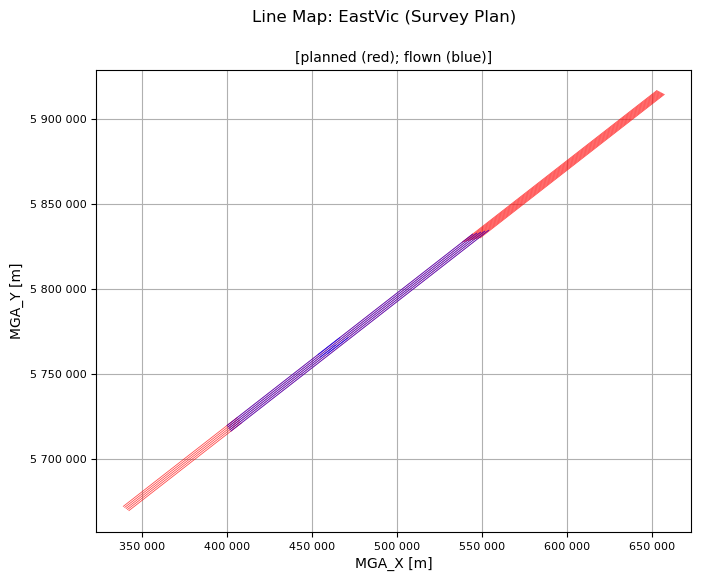

In [32]:
qc.linesMap([EastVicHDF_file], whizzPlanFile=EastVicHDF_plan)

The test and repeat line numbers do not appear in the plan file, and so they are not shown in the line map above. But if we do not provide a plan file, then `linesMap` will plot them.

No file of planned data provided.


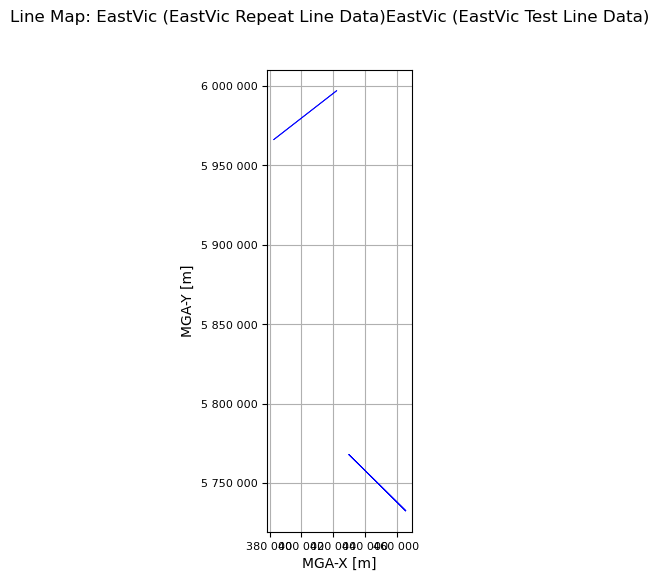

In [33]:
qc.linesMap([EastVicRepHDF_file, EastVicTestHDF_file])